In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 1: Loading the Dataset
try:
    # IMPORTANT: Your file name must be exactly 'credit_risk_dataset.csv'
    df = pd.read_csv('credit_risk_dataset.csv')
    print("Step 1: Dataset loaded successfully.")

    # Step 2: Handling Missing Values
    # Filling empty spaces in 'employment length' and 'interest rate' with median
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
    print("Step 2: Missing values handled.")

    # Step 3: Categorical Encoding
    # Converting text columns (Home ownership, Intent) into numbers
    df_final = pd.get_dummies(df, drop_first=True)
    print("Step 3: Categorical data encoded.")

    # Step 4: Split data into X (Features) and y (Target)
    X = df_final.drop('loan_status', axis=1)
    y = df_final['loan_status']

    # Step 5: Train/Test Split (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Step 4 & 5: Data split for training.")

    # Step 6: Initializing and Training the Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)  
    model.fit(X_train, y_train)
    print("Step 6: Model training complete.")

    # Step 7: Checking Accuracy
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("\n--- FINAL RESULT ---")
    print(f"Model Accuracy: {accuracy * 100:.2f}%")

except FileNotFoundError:
    print("ERROR: CSV file not found! Check if the file is in the same folder.")
except Exception as e:
    print(f"ERROR: {e}")

Step 1: Dataset loaded successfully.
Step 2: Missing values handled.
Step 3: Categorical data encoded.
Step 4 & 5: Data split for training.
Step 6: Model training complete.

--- FINAL RESULT ---
Model Accuracy: 92.86%


C:\Users\user\AppData\Local\Temp\ipykernel_4508\1046574795.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


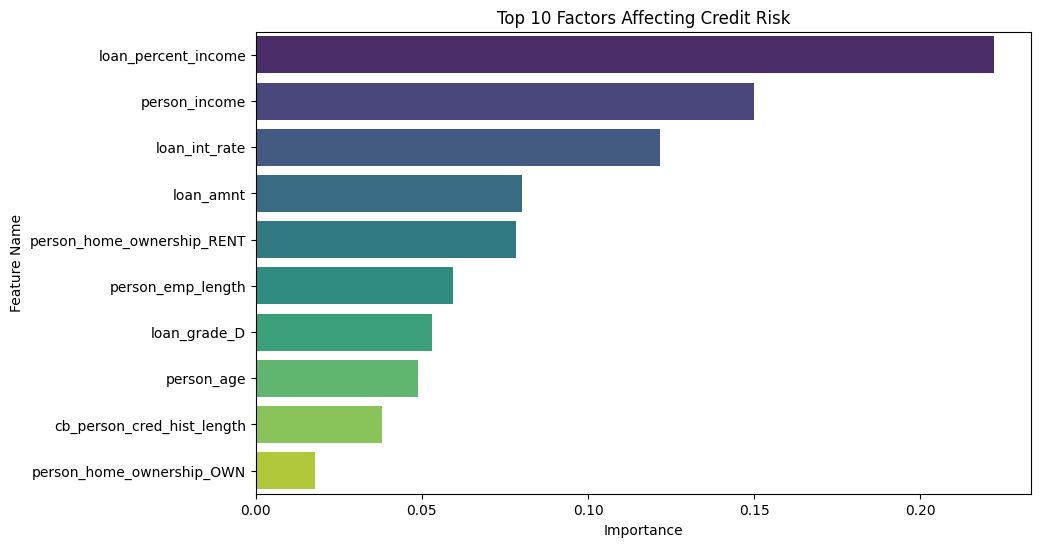

Graph displayed successfully!


: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Check if model exists and draw graph
try:
    # We take 'model' and 'X' from the previous successful run
    importances = model.feature_importances_
    feature_names = X.columns
    
    # Selecting top 10 important factors
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

    # Drawing the Bar Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title('Top 10 Factors Affecting Credit Risk')
    plt.xlabel('Importance')
    plt.ylabel('Feature Name')
    plt.show()
    print("Graph displayed successfully!")

except NameError:
    print("Error: 'model' or 'X' is not defined. Please run the previous model training cell first.")
except Exception as e:
    print(f"Error: {e}")